## Import Functions

In [1]:
from __future__ import annotations

# === Standard Library ===
import logging
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from typing import Any, Iterable, Optional, Type, Union
import datetime

# === Third-Party Libraries ===
import pandas as pd
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
import jiwer

import torch
from torch import Tensor

import whisper
import soundfile as sf

from huggingface_hub import hf_hub_download

import yaml
import phonemizer
from phonemizer.backend import EspeakBackend

from nltk.cluster import cosine_distance
from nltk.tokenize import word_tokenize

from sentence_transformers import SentenceTransformer, util
from transformers import GPT2Tokenizer, GPT2LMHeadModel, Wav2Vec2Model, Wav2Vec2Processor
import math

import IPython.display as ipd

# === Pymoo Optimization Framework ===
from _pymoo_optimizer import PymooOptimizer

from pymoo.algorithms.base.genetic import GeneticAlgorithm
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.evaluator import Evaluator
from pymoo.core.population import Population
from pymoo.core.problem import Problem
from pymoo.core.termination import NoTermination
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.problems.static import StaticProblem

# === StyleTTS2 Local Modules ===
from models import *
from utils import *
from text_utils import TextCleaner
from Utils.PLBERT.util import load_plbert
from Modules.diffusion.sampler import DiffusionSampler, ADPM2Sampler, KarrasSchedule

# === Import from Files ===
from _helper import length_to_mask, addNumbersPattern, interpolateWithVector, interpolateWithScalar
from _pymoo_optimizer import PymooOptimizer
from _styletts2 import StyleTTS2

%cd ..

W1201 22:45:52.538537 5704 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


C:\Users\Yanis Wilbrand\PycharmProjects\StyleTTS2


C:\Users\Yanis Wilbrand\.conda\envs\styletts2\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Create Helper Functions


In [2]:
def text_naturalness_from_ppl(ppl, min_loss=1.0, max_loss=10.0):
    """
    ppl: perplexity from your LM
    Returns score in [0,1], where 1 = very natural/common.
    """
    loss = math.log(ppl)             # log PPL = cross-entropy-ish
    loss = max(min(loss, max_loss), min_loss)
    return 1.0 - (loss - min_loss) / (max_loss - min_loss)

In [3]:
def compute_wer_score(reference, hypothesis):
    """
    Computes Word Error Rate (WER) with robust normalization.

    Pipeline:
    1. Expands contractions (don't -> do not)
    2. Lowercases & strips whitespace
    3. Removes punctuation
    4. Calculates Levenshtein distance

    Returns:
        float: The WER score (0.0 is perfect, >1.0 is possible if many insertions)
    """

    # 1. Define the normalization pipeline
    # The order matters: Expand contractions BEFORE removing punctuation.
    transforms = jiwer.Compose([
        jiwer.ExpandCommonEnglishContractions(),
        jiwer.RemoveEmptyStrings(),
        jiwer.ToLowerCase(),
        jiwer.RemoveMultipleSpaces(),
        jiwer.Strip(),
        jiwer.RemovePunctuation(),
        jiwer.ReduceToListOfListOfWords(),
    ])

    # 2. Calculate WER
    # Note: older versions used 'truth_transform', new versions use 'reference_transform'
    wer = jiwer.wer(
        reference,
        hypothesis,
        reference_transform=transforms,
        hypothesis_transform=transforms,
    )

    return float(wer)

## Classes

In [4]:
class AutomaticSpeechRecognitionModel:
    def __init__(self, model_name="tiny", device = "cuda" if torch.cuda.is_available() else "cpu"):
        self.model = whisper.load_model(model_name, device=device)

    def analyzeAudio(self, wav: torch.Tensor) -> tuple[dict, float]:
        result = self.model.transcribe(audio=wav)

        total_logprob = 0.0
        total_tokens = 0
        for seg in result["segments"]:
            total_logprob += seg["avg_logprob"] * len(seg["tokens"])
            total_tokens += len(seg["tokens"])

        avg_logprob = total_logprob / total_tokens if total_tokens > 0 else float("nan")
        return result, avg_logprob

## Main Function

### Initializes Values

In [18]:
ACTIVE_OBJECTIVES = ["wav2vec-target", "utmos"]

diffusion_steps = 5
embedding_scale = 1

interpolation_percentage = 0.4 # How much of Target to be used, small interpolation_percentage means more of ground_truth (Minimization)

name_gt = "ground_truth"
text_gt = "I think the NFL is lame and boring"

name_target = "target"
text_target = "The Seattle Seahawks are the best Team in the world"

### Load Models

In [22]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

tts_model = StyleTTS2()
tts_model.load_models()  # builds self.model and loads self.params
tts_model.load_checkpoints()  # puts params into self.model
tts_model.sample_diffusion()  # builds self.sampler

noise_gt = torch.randn(1, 1, 256).to(tts_model.device)
noise_target = torch.randn(1, 1, 256).to(tts_model.device)

h_text_gt, h_bert_raw_gt, h_bert_gt, h_text_target, h_bert_raw_target, h_bert_target, input_lengths, text_mask, style_vector_acoustic, style_vector_prosodic = tts_model.extract_mixed_embeddings(text_gt, text_target, noise_target, embedding_scale, diffusion_steps)

audio_gt = tts_model.inference_after_interpolation(input_lengths, text_mask, h_bert_gt, h_text_gt, style_vector_acoustic, style_vector_prosodic)
audio_target = tts_model.inference_after_interpolation(input_lengths, text_mask, h_bert_target, h_text_target, style_vector_acoustic, style_vector_prosodic)

asr_model = AutomaticSpeechRecognitionModel("tiny", device=device)

if "text-embedding-target" in ACTIVE_OBJECTIVES or "text-embedding-gt" in ACTIVE_OBJECTIVES:
    embedding_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device=device)

    text_embedding_gt = embedding_model.encode(text_gt, convert_to_tensor=True, normalize_embeddings=True)
    text_embedding_target = embedding_model.encode(text_target, convert_to_tensor=True, normalize_embeddings=True)

if "utmos" in ACTIVE_OBJECTIVES:
    utmos_model = torch.jit.load(
        hf_hub_download(
            repo_id="balacoon/utmos",
            filename="utmos.jit",
            repo_type="model",
            local_dir="./"
        ),
    ).to(device)

if "s-bert-target" in ACTIVE_OBJECTIVES or "s-bert-gt" in ACTIVE_OBJECTIVES:
    sbert_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

    s_bert_embedding_gt = sbert_model.encode(text_gt, convert_to_tensor=True, normalize_embeddings=True)
    s_bert_embedding_target = sbert_model.encode(text_target, convert_to_tensor=True, normalize_embeddings=True)


if "ppl" in ACTIVE_OBJECTIVES:
    perplexity_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    perplexity_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

if "wav2vec-gt" in ACTIVE_OBJECTIVES or "wav2vec-target" in ACTIVE_OBJECTIVES:
    wav2vec_processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-large-960h-lv60-self")
    wav2vec_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-large-960h-lv60-self").to(device)
    wav2vec_model.eval()

    with torch.no_grad():
        wav2vec_embedding_gt = torch.mean(wav2vec_model(**wav2vec_processor(audio_gt, return_tensors="pt", sampling_rate=16000).to(device)).last_hidden_state, dim=1)
        wav2vec_embedding_target = torch.mean(wav2vec_model(**wav2vec_processor(audio_target, return_tensors="pt", sampling_rate=16000).to(device)).last_hidden_state, dim=1)

C:\Users\Yanis Wilbrand\.conda\envs\styletts2\lib\site-packages\huggingface_hub\file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-large-960h-lv60-self and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Optimizer

#### Initialize Optimizer

In [23]:
pop_size = 100
num_generations = 100
num_objectives = ACTIVE_OBJECTIVES.__len__()
solution_shape = (int(input_lengths.detach().cpu().item()),)  # 16 decision variables per individual

# Genetic algorithm parameters
algo_params = {
    "pop_size": pop_size,
}

optimizer = PymooOptimizer(
    bounds=(0, 1),
    algorithm=NSGA2,  # pass the class, not NSGA2(...)
    algo_params=algo_params,
    num_objectives=num_objectives,
    solution_shape=solution_shape,
)

#### Loop

In [25]:
# 1. Initialize a list to hold all records
fitness_history = []
mean_model = []


for gen in range(num_generations):

    gen_scores = {key: [] for key in ACTIVE_OBJECTIVES}

    # 1) Get current population
    population_vectors = optimizer.get_x_current()  # shape: (pop_size, *solution_shape)

    # Debugging
    print(f"=== Generation {gen} ===")

    for j, interpolation_vector in enumerate(population_vectors):

        # Ensure vector is on the correct device
        interpolation_vector = torch.from_numpy(interpolation_vector).to(h_text_gt.device).float()

        # Interpolate Values
        h_text_mixed = interpolateWithVector(h_text_gt, h_text_target, interpolation_vector)
        h_bert_mixed = h_bert_gt

        # Inference
        audio_mixed = tts_model.inference_after_interpolation(
            input_lengths,
            text_mask,
            h_bert_mixed,
            h_text_mixed,
            style_vector_acoustic,
            style_vector_prosodic
        )

        # ASR Analysis
        asr_result, asr_confidence = asr_model.analyzeAudio(audio_mixed)
        asr_text = asr_result["text"]

        current_ind_scores = {}

        # --- Calculate Fitness Functions ---
        if "l1" in ACTIVE_OBJECTIVES:
            # Minimize Interpolation Vector (L1-Norm)
            val = float(interpolation_vector.abs().mean().item())
            gen_scores["l1"].append(val)
            current_ind_scores["L1_Norm"] = val

        if "l2" in ACTIVE_OBJECTIVES:
            # Minimize Interpolation Vector (L2-Norm)
            val = (interpolation_vector ** 2).mean().item()
            gen_scores["l2"].append(val)
            current_ind_scores["L2_Norm"] = val

        if "wer" in ACTIVE_OBJECTIVES:
            # Minimize Word Error Rate
            val = compute_wer_score(text_target, asr_text)
            gen_scores["wer"].append(val)
            current_ind_scores["WER_Score"] = val

        if "s-bert-target" in ACTIVE_OBJECTIVES:
            # 1. Compute Embedding of ASR result
            s_bert_embedding_asr = sbert_model.encode(asr_text, convert_to_tensor=True, normalize_embeddings=True)

            # 2. Compute Similarity (1.0 is best)
            val = 1.0 - util.cos_sim(s_bert_embedding_target, s_bert_embedding_asr).item()

            # 3. Store
            gen_scores["s-bert-target"].append(val)
            current_ind_scores["S-BERT-Target"] = val

        if "s-bert-gt" in ACTIVE_OBJECTIVES:
            # 1. Compute Embedding of ASR result
            s_bert_embedding_asr = sbert_model.encode(asr_text, convert_to_tensor=True, normalize_embeddings=True)

            # 2. Compute Similarity (1.0 is best)
            val = util.cos_sim(s_bert_embedding_gt, s_bert_embedding_asr).item()

            # 3. Store
            gen_scores["s-bert-gt"].append(val)
            current_ind_scores["S-BERT-Ground-Truth"] = val

        if "text-embedding-gt" in ACTIVE_OBJECTIVES:
            # Maximize Embedding Distance (Ground Truth)
            text_embedding_mixed = embedding_model.encode(asr_text, convert_to_tensor=True, normalize_embeddings=True)
            val = - (1.0 - F.cosine_similarity(text_embedding_gt, text_embedding_mixed, dim=1).item())
            gen_scores["text-embedding-gt"].append(val)
            current_ind_scores["Text-Embedding-Distance-GT"] = val

        if "text-embedding-target" in ACTIVE_OBJECTIVES:
            # Minimize Embedding Distance (Target)
            text_embedding_mixed = embedding_model.encode(asr_text, convert_to_tensor=True, normalize_embeddings=True)
            val = 1.0 - F.cosine_similarity(text_embedding_target, text_embedding_mixed, dim=1).item()
            gen_scores["text-embedding-target"].append(val)
            current_ind_scores["Text-Embedding-Distance-Target"] = val

        if "avg-logprob" in ACTIVE_OBJECTIVES:
            # Maximize ASR Confidence
            val = - asr_confidence
            gen_scores["avg-logprob"].append(val)
            current_ind_scores["Average-Log-Probability"] = val

        if "utmos" in ACTIVE_OBJECTIVES:
            val = - utmos_model(torch.from_numpy(audio_mixed).float().unsqueeze(0).to(next(utmos_model.parameters()).device)).item()
            gen_scores["utmos"].append(val)
            current_ind_scores["UTMOS"] = val

        if "wav2vec-gt" in ACTIVE_OBJECTIVES:
            wav2vec_embedding_mixed = torch.mean(wav2vec_model(**wav2vec_processor(audio_mixed, return_tensors="pt", sampling_rate=16000).to(device)).last_hidden_state, dim=1)
            val = 1 - F.cosine_similarity(wav2vec_embedding_gt, wav2vec_embedding_mixed).item()
            gen_scores["wav2vec-gt"].append(val)
            current_ind_scores["wav2vec-ground-truth"] = val

        if "wav2vec-target" in ACTIVE_OBJECTIVES:
            wav2vec_embedding_mixed = torch.mean(wav2vec_model(**wav2vec_processor(audio_mixed, return_tensors="pt", sampling_rate=16000).to(device)).last_hidden_state, dim=1)
            val = 1 - F.cosine_similarity(wav2vec_embedding_target, wav2vec_embedding_mixed).item()
            gen_scores["wav2vec-target"].append(val)
            current_ind_scores["wav2vec-target"] = val

        # 2. Store individual record
        record = {"Generation": gen, "Individual_ID": j}
        record.update(current_ind_scores)
        fitness_history.append(record)

    # 3. Calculate Means dynamically
    gen_mean = {"Generation": gen}
    fitness_arrays_for_optimizer = []

    # Iterate over ACTIVE_OBJECTIVES to ensure order is preserved for optimizer
    for key in ACTIVE_OBJECTIVES:
        # Convert list to array
        arr = np.array(gen_scores[key], dtype=float)

        # Store mean for dataframe
        gen_mean[f"{key}_Mean"] = np.mean(arr)

        # Prepare list for optimizer
        fitness_arrays_for_optimizer.append(arr)

    mean_model.append(gen_mean)

    # 4. Update Optimizer
    optimizer.assign_fitness(fitness_arrays_for_optimizer)
    optimizer.update()

=== Generation 0 ===
=== Generation 1 ===
=== Generation 2 ===
=== Generation 3 ===
=== Generation 4 ===
=== Generation 5 ===
=== Generation 6 ===
=== Generation 7 ===
=== Generation 8 ===
=== Generation 9 ===
=== Generation 10 ===
=== Generation 11 ===
=== Generation 12 ===
=== Generation 13 ===
=== Generation 14 ===
=== Generation 15 ===
=== Generation 16 ===
=== Generation 17 ===
=== Generation 18 ===
=== Generation 19 ===
=== Generation 20 ===
=== Generation 21 ===
=== Generation 22 ===
=== Generation 23 ===
=== Generation 24 ===
=== Generation 25 ===
=== Generation 26 ===
=== Generation 27 ===
=== Generation 28 ===
=== Generation 29 ===
=== Generation 30 ===
=== Generation 31 ===
=== Generation 32 ===
=== Generation 33 ===
=== Generation 34 ===
=== Generation 35 ===
=== Generation 36 ===
=== Generation 37 ===
=== Generation 38 ===
=== Generation 39 ===
=== Generation 40 ===
=== Generation 41 ===
=== Generation 42 ===
=== Generation 43 ===
=== Generation 44 ===
=== Generation 45 ==

#### Inference after Interpolation

In [26]:
# Convert the history list to a DataFrame
df_all_fitness = pd.DataFrame(fitness_history)

# Convert the median tracking to a DataFrame (easier to plot later)
df_means = pd.DataFrame(mean_model)

In [27]:
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")

folder_path = f"outputs/h_text/{'_'.join(ACTIVE_OBJECTIVES)}/{timestamp}/"

os.makedirs(folder_path, exist_ok=True)

##### Graph

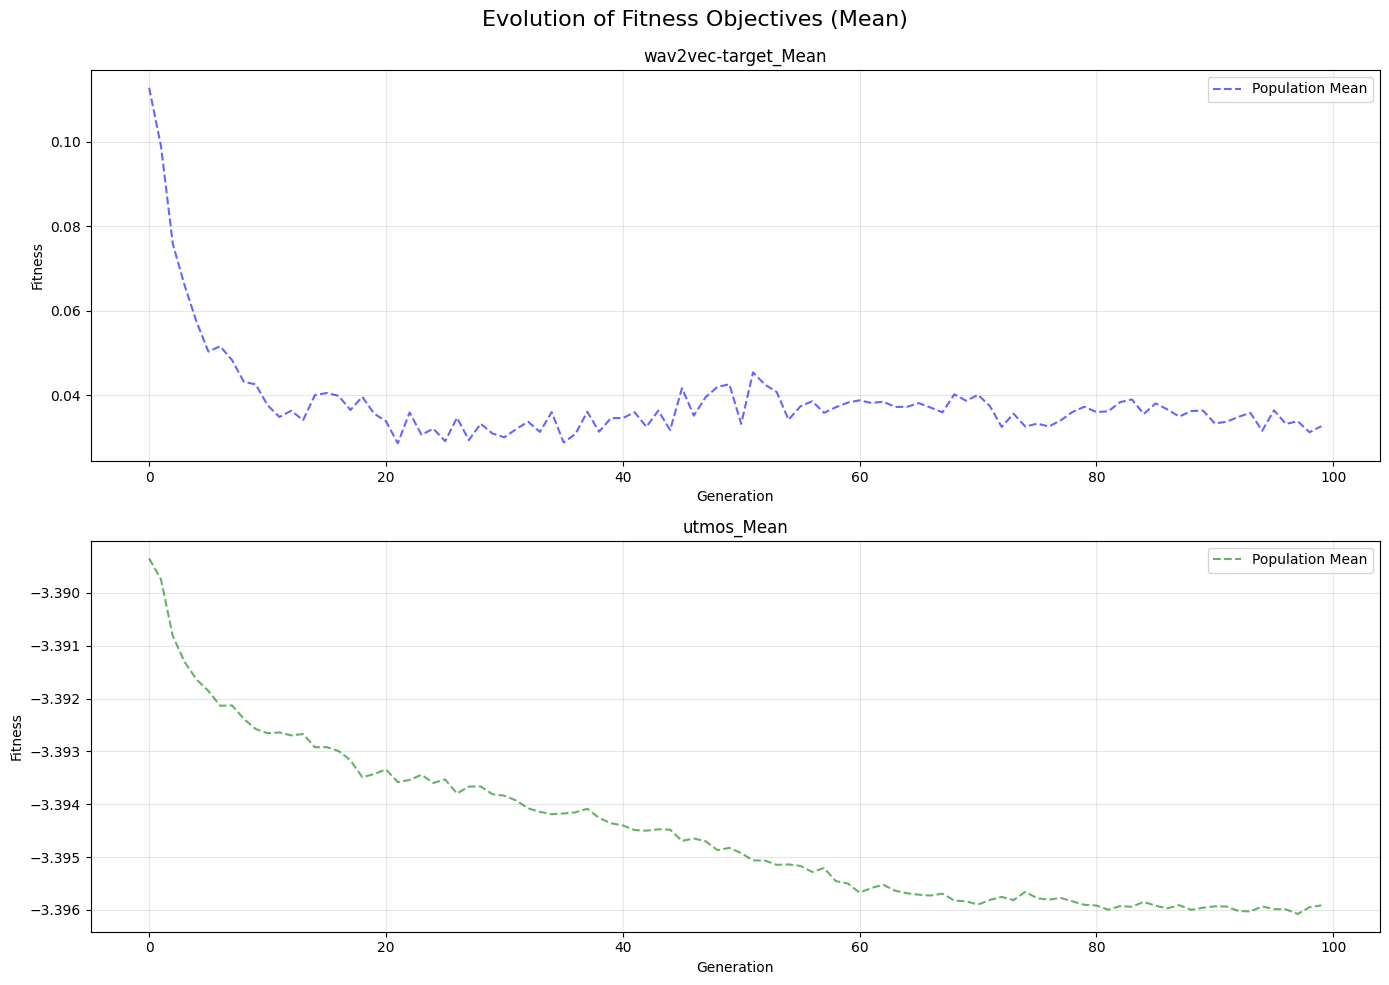

In [28]:
# Filters out 'Generation' and grabs everything else (e.g., 'f1_Mean', 'f3_Mean')
fitness_cols = [col for col in df_means.columns if 'Mean' in col and col != 'Generation']

# 2. Create dynamic labels (optional, you can map them if you want specific names)
# If you want specific names, map them here. Otherwise, it defaults to the column name.
name_map = {
    "f1_Mean": "f1 (L1 Norm)",
    "f2_Mean": "f2 (Emb Dist GT)",
    "f3_Mean": "f3 (Emb Dist Target)",
    "f4_Mean": "f4 (ASR Confidence)"
}

# 3. Setup Plot
fig, axs = plt.subplots(len(fitness_cols), 1, figsize=(14, 5 * len(fitness_cols)))
if len(fitness_cols) == 1: axs = [axs] # Handle single plot edge case
fig.suptitle("Evolution of Fitness Objectives (Mean)", fontsize=16)

# 4. Loop through the EXISTING columns
for j, col_name in enumerate(fitness_cols):

    x_data = df_means['Generation']
    y_data = df_means[col_name]

    # Get a nice label if available, otherwise use column name
    plot_label = name_map.get(col_name, col_name)
    color = 'blue' if j % 2 == 0 else 'green' # Alternate colors

    axs[j].plot(x_data, y_data,
                color=color,
                linestyle='--',
                alpha=0.6,
                label="Population Mean")

    axs[j].set_title(plot_label)
    axs[j].set_xlabel("Generation")
    axs[j].set_ylabel("Fitness")
    axs[j].grid(True, alpha=0.3)
    axs[j].legend()

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Make room for suptitle
plt.savefig(folder_path+f"graph.png", dpi=300, bbox_inches='tight')
plt.show()

##### Best Candidate

In [29]:
print("=== Synthesis of Best Candidate After Optimization ===")

# 1) Get best candidate(s) from optimizer
best_candidates = optimizer.best_candidates

if len(best_candidates) == 0:
    raise RuntimeError("Optimizer has no best candidates. Did training run correctly?")

best = best_candidates[0]   # first Pareto-optimal candidate

# 2) Print FITNESS values dynamically
print("Best candidate fitness values:")
# Ensure the length of fitness values matches your active objectives
if len(best.fitness) != len(ACTIVE_OBJECTIVES):
    print(f"Warning: Number of fitness values ({len(best.fitness)}) does not match ACTIVE_OBJECTIVES ({len(ACTIVE_OBJECTIVES)}). Printing raw values.")
    print(f"  Raw Fitness: {best.fitness}")
else:
    for obj_name, score in zip(ACTIVE_OBJECTIVES, best.fitness):
        print(f"  {obj_name}: {score:.6f}")
print()

# 3) Extract interpolation vector
best_vector = torch.tensor(best.solution, device=tts_model.device).float()

# 4) Create mixed embeddings using the best vector
# Note: Ensure h_bert_mixed logic matches your loop (sometimes it's fixed to GT, sometimes interpolated)
h_text_mixed_best = interpolateWithVector(h_text_gt, h_text_target, best_vector)
h_bert_mixed_best = h_bert_gt # Usually BERT is kept fixed to GT for stability, change if your logic differs

# 5) Run TTS inference for:
#    - ground-truth
#    - target
#    - best mixed candidate
with torch.no_grad():
    # Ground-truth audio
    audio_gt = tts_model.inference_after_interpolation(
        input_lengths,
        text_mask,
        h_bert_gt,
        h_text_gt,
        style_vector_acoustic,
        style_vector_prosodic,
    )

    # Target audio
    audio_target = tts_model.inference_after_interpolation(
        input_lengths,
        text_mask,
        h_bert_target,
        h_text_target,
        style_vector_acoustic,
        style_vector_prosodic,
    )

    # Best mixed candidate audio
    audio_best = tts_model.inference_after_interpolation(
        input_lengths,
        text_mask,
        h_bert_mixed_best,
        h_text_mixed_best,
        style_vector_acoustic,
        style_vector_prosodic,
    )

# 6) Run ASR on final audio and print predicted text
# Only run if you have the resources/need, but good for validation
asr_final, conf_final = asr_model.analyzeAudio(audio_best)
predicted_text_final = asr_final["text"].strip()

print("ASR Transcription of Best Candidate:")
print(f'  "{predicted_text_final}"')
print(f"  ASR confidence (avg_logprob) = {conf_final}")
print()

# 7) Play all three audios: GT, target, and mixed best
print("=== Ground-truth Audio ===")
display(ipd.Audio(audio_gt, rate=24000))

print("=== Target Audio ===")
display(ipd.Audio(audio_target, rate=24000))

print("=== Best Mixed Candidate Audio ===")
display(ipd.Audio(audio_best, rate=24000))

=== Synthesis of Best Candidate After Optimization ===
Best candidate fitness values:
  wav2vec-target: 0.004070
  utmos: -3.395508

ASR Transcription of Best Candidate:
  "I think the Seahorse is lame and boring."
  ASR confidence (avg_logprob) = -0.7060926982334682

=== Ground-truth Audio ===


=== Target Audio ===


=== Best Mixed Candidate Audio ===


In [13]:
state_dict = {
    # The Core Result (converted to Tensor for immediate use next time)
    "interpolation_vector": torch.tensor(best.solution).float().cpu(),

    # Metadata (So you know how good it was)
    "fitness_values": best.fitness,
    "active_objectives": ACTIVE_OBJECTIVES,

    # Configuration (Optional: Save text inputs so you can reproduce audio)
    "text_gt": text_gt, # or text_gt depending on your variable name
    "text_target": text_target,
    "asr_text": asr_text,

    # Generation info
    "generation_found": getattr(best, "generation", "Unknown") # if your optimizer tracks this
}

torch.save(state_dict, folder_path + f"best_vector.pt")

In [14]:
sf.write(folder_path + "ground_truth.wav", audio_gt, samplerate=24000)
sf.write(folder_path + "target.wav", audio_target, samplerate=24000)
sf.write(folder_path + "interpolated.wav", audio_best, samplerate=24000)

## Load from state_dict

In [15]:
loading_folder_path = r"outputs\h_text\l1_wer\20251130_1826"

In [16]:
# 1. Load the dictionary from the file
loaded_state_dict = torch.load(os.path.join(loading_folder_path, "best_vector.pt"), weights_only=False)

# 2. Extract the variables back out
interpolation_vector = loaded_state_dict["interpolation_vector"]
h_text_mixed_best = interpolateWithVector(h_text_gt, h_text_target, best_vector)
fitness_values = loaded_state_dict["fitness_values"]
active_objectives = loaded_state_dict["active_objectives"]

# Extracting text data
text_gt = loaded_state_dict["text_gt"]
text_target = loaded_state_dict["text_target"]
# asr_text = loaded_state_dict["asr_text"]

# Extracting metadata
generation_found = loaded_state_dict["generation_found"]



# Verification print
print(f"Loaded vector shape: {interpolation_vector.shape}")
# print(f"ASR Text: {asr_text}")
print(f"Fitness: {fitness_values}")

Loaded vector shape: torch.Size([53])
Fitness: [0.15038864 0.43531972]


### Load Audio

In [17]:

y, sr = librosa.load(os.path.join(loading_folder_path, "interpolated.wav"), sr=None) # sr=None keeps the original sample rate

asr_final, conf_final = asr_model.analyzeAudio(y)
predicted_text_final = asr_final["text"].strip()

print(f"ASR Transcription of Best Candidate: {predicted_text_final}")

ASR Transcription of Best Candidate: I think the NFL's is way best point.
